<a href="https://colab.research.google.com/github/farrelrassya/ensemble-methods-machine-learning/blob/main/ch8_categorical_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 8 — Learning with Categorical Features

This notebook is a unified, end-to-end walkthrough of **Chapter 8** of *Ensemble Methods for Machine Learning* by Gautam Kunapuli. It merges the three original section notebooks into a single, executable Colab-friendly document that covers:

- **8.1** Encoding categorical features — ordinal, one-hot, greedy target, leave-one-out target encoding
- **8.2** CatBoost — ordered target statistics, ordered boosting, and oblivious decision trees
- **8.3** Case study — income prediction on the UCI Adult dataset, comparing **10 model–encoder combinations**
- **8.4** High-cardinality string features — `dirty_cat` similarity, MinHash, and Gap encoders

### Why this chapter matters

Every previous chapter assumed your features were already numeric. In the real world, they almost never are: a credit-card transaction has **merchant category code** (categorical), a job applicant has **education level** (ordinal), a customer has **ZIP code** (categorical with $\sim 42{,}000$ levels in the US). Before any of the powerful boosting machinery from Chapters 5–7 can run, you must convert these categories into numbers — and that conversion step is where most production ML pipelines silently bleed accuracy.

Three reasons categorical encoding deserves its own chapter:

1. **The wrong encoding hurts more than you think.** One-hot encoding a $385$-level job-title column adds $385$ near-empty columns to your data, exploding memory and starving each tree of information. Ordinal encoding *invents an ordering* between unrelated categories ("blue" $<$ "green" $<$ "red") that misleads downstream models.

2. **Target encoding leaks.** Replacing each category with the mean target value of training examples in that category is a powerful encoding — but doing it naively *contaminates the training set with target information*. A model evaluated on this contaminated training set looks great in CV and then disappoints in production.

3. **CatBoost solves the leakage problem from inside the algorithm.** Yandex's CatBoost integrates **ordered target statistics** + **ordered boosting** + **oblivious decision trees** to handle categorical features natively, with built-in protection against target leakage and prediction shift. Understanding *why* CatBoost is designed this way is the strategic insight of this chapter.

### What you will be able to do after this notebook

1. Pick the right encoder for any categorical feature: ordinal for true rankings, one-hot for low-cardinality nominals, target encoding for high-cardinality with leakage controls.
2. Build a leak-proof preprocessing pipeline using `category_encoders` + scikit-learn's `ColumnTransformer`.
3. Train and tune CatBoost with `cat_features`, grid search, and early stopping.
4. Compare 10 encoder × ensemble combinations on a real benchmark and reason about which to deploy.
5. Handle dirty, high-cardinality string features (job titles, addresses, free-text categories) with `dirty_cat`.

## Environment setup

Three categorical-encoding packages on top of the standard ML stack: `category_encoders`, `catboost`, and `dirty_cat`. The first ships supervised and unsupervised encoders; the second is Yandex's gradient-boosting framework; the third specializes in high-cardinality and noisy string features.

In [19]:
# Install required packages
!pip install -q category_encoders catboost dirty_cat lightgbm xgboost seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Reproducibility
np.random.seed(42)
pd.options.display.float_format = '{:,.4f}'.format

---
## 8.1 Encoding categorical features

Most ML algorithms expect numeric input. Categories like `red`, `blue`, `green` or `S`, `M`, `L`, `XL` need to be transformed into numbers before training.

### 8.1.1 Two types of categorical features

| Type | Definition | Examples | Right encoding |
|---|---|---|---|
| **Nominal** | No inherent ordering between categories | colors, cities, ZIP codes, marital status | One-hot, target encoding |
| **Ordinal** | Implicit ordering between categories | shirt size (S < M < L < XL), education (High School < Bachelor's < Master's < PhD) | Ordinal encoding |

We will explore both with a tiny **synthetic T-shirt dataset** of 8 examples, two features (`color` is nominal, `size` is ordinal), and a continuous price target.

In [20]:
import numpy as np
X = np.array([['red', 'M'],
              ['green', 'L'],
              ['red', 'S'],
              ['blue', 'XL'],
              ['blue', 'S'],
              ['green', 'XL'],
              ['blue', 'M'],
              ['red', 'L']])

**The T-shirt dataset in matrix form.** Eight rows, two string columns. `color` $\in \{$red, green, blue$\}$ has no natural ordering. `size` $\in \{$S, M, L, XL$\}$ has a natural ordering S $<$ M $<$ L $<$ XL. Storing strings directly is fine for inspection but unusable for training — we need to encode.

### 8.1.2 Ordinal encoding

**Ordinal encoding** assigns each category a single integer. For an ordinal feature like `size`, the integers should preserve the ordering: $\{S \to 0, M \to 1, L \to 2, XL \to 3\}$ or its reverse.

For a nominal feature, ordinal encoding **invents an ordering that does not exist in reality** — but it is fast, compact, and works fine for tree-based models that split on values rather than distances.

In [21]:
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder(categories=[['red', 'yellow', 'green', 'blue'],
                                     ['XL', 'L', 'M', 'S']])
Xenc = encoder.fit_transform(X)

We deliberately tell `OrdinalEncoder` that `color` could take *four* possible values $\{$red, yellow, green, blue$\}$ even though `yellow` is absent from our 8 examples. This is a useful pattern in production: declare the full *known* category set, not just what happens to appear in your training sample. We also reverse the natural ordering for `size` to $\{$XL, L, M, S$\}$ — for nominal features, the ordering is arbitrary anyway, so we can pick whatever integer convention is convenient.

In [22]:
encoder.categories_

[array(['red', 'yellow', 'green', 'blue'], dtype=object),
 array(['XL', 'L', 'M', 'S'], dtype=object)]

**The category-to-integer mapping.** `encoder.categories_` shows the integer that each category will map to (the *index* in each array becomes the integer):

- `color`: $\{\text{red} \to 0,\ \text{yellow} \to 1,\ \text{green} \to 2,\ \text{blue} \to 3\}$
- `size`: $\{\text{XL} \to 0,\ \text{L} \to 1,\ \text{M} \to 2,\ \text{S} \to 3\}$

(Note: a typo in the original output displays "yello" instead of "yellow" — that is just `numpy`'s string truncation at 5 characters; the actual stored value is correct.)

In [23]:
Xenc

array([[0., 2.],
       [2., 1.],
       [0., 3.],
       [3., 0.],
       [3., 3.],
       [2., 0.],
       [3., 2.],
       [0., 1.]])

**The encoded data matrix.** Each row of the 8 × 2 matrix is now one example with two integer-encoded features. For example, row 0 was `(red, M)` and is now `[0., 2.]` — `red` $\to 0$, `M` $\to 2$. Row 3 was `(blue, XL)` $\to [3., 0.]$.

**Three observations to take away.**

1. **Same shape as input.** $8 \times 2 \to 8 \times 2$. Ordinal encoding is *dimension-preserving*.
2. **No yellow appears in column 0.** The integer `1` is reserved for yellow but unused in our 8 rows. Including the unused category in the encoding fit is a defensive choice that prevents pipeline failures when yellow shows up at inference time.
3. **The hidden ordering hazard.** A linear model using these encoded features would learn that `red < yellow < green < blue`, which is meaningless. **Tree-based models (random forests, XGBoost, CatBoost) are immune to this** because they split on values directly, not distances. **Linear/kernel models (logistic regression, SVM, kNN) are *not* immune** — for those, use one-hot or target encoding.

### One-hot encoding

**One-hot encoding** replaces each $K$-category column with $K$ binary columns: each category becomes a $K$-dimensional vector with a single 1 and $(K-1)$ zeros.

For our 3-color, 4-size example:

$$\text{red} \to [1, 0, 0], \quad \text{green} \to [0, 1, 0], \quad \text{blue} \to [0, 0, 1]$$

$$\text{S} \to [1, 0, 0, 0], \quad \text{M} \to [0, 1, 0, 0], \quad \text{L} \to [0, 0, 1, 0], \quad \text{XL} \to [0, 0, 0, 1]$$

This **eliminates any spurious ordering** at the cost of expanding the feature space from $1 \to K$ columns per categorical feature. For a $K = 50$ US-state column, that is a $50\times$ blow-up. For ZIP codes ($K \approx 42{,}000$), one-hot is infeasible.

In [24]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(categories=[['red', 'green', 'blue'],
                                     ['S', 'M', 'L', 'XL']])
Xenc = encoder.fit_transform(X)

In [25]:
encoder.categories_

[array(['red', 'green', 'blue'], dtype=object),
 array(['S', 'M', 'L', 'XL'], dtype=object)]

**Confirmed category orderings:**

- `color`: $[\text{red}, \text{green}, \text{blue}]$ — column index defines which slot is "1".
- `size`: $[\text{S}, \text{M}, \text{L}, \text{XL}]$ — note `OneHotEncoder` reorders alphabetically by default, but we passed an explicit `categories=` argument so this matches our desired order.

In [26]:
Xenc.toarray()

array([[1., 0., 0., 0., 1., 0., 0.],
       [0., 1., 0., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 1.],
       [0., 0., 1., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0., 1., 0.]])

**The 8 × 7 one-hot matrix.** Read each row as `[red, green, blue, S, M, L, XL]`:

| Row | Original | One-hot |
|---|---|---|
| 0 | (red, M) | $[1,0,0,\ 0,1,0,0]$ |
| 1 | (green, L) | $[0,1,0,\ 0,0,1,0]$ |
| 2 | (red, S) | $[1,0,0,\ 1,0,0,0]$ |
| 3 | (blue, XL) | $[0,0,1,\ 0,0,0,1]$ |
| ... | ... | ... |

**The dimensional cost is real.** $8 \times 2 \to 8 \times 7$. With $3 + 4 = 7$ unique categories, we now have $7$ columns. For larger datasets, the math becomes painful: a feature with $50$ categories adds $50$ columns; with $1{,}000$ categories, it adds $1{,}000$ columns. Most of these columns are **sparse** (mostly zero), which is why scikit-learn returns a `scipy.sparse` matrix by default — calling `.toarray()` densifies it for inspection.

**Production rule of thumb:** one-hot encoding works well up to $\sim 50$ categories per feature. Beyond that, prefer target encoding or hashing-based encoders (which we will see in section 8.4).

### 8.1.3 Encoding with target statistics

**Target encoding** (also called *mean encoding*) replaces each category with a statistic — typically the **mean of the target** for examples in that category. It is a *supervised* encoding because it uses the labels.

For our T-shirt dataset, the three red T-shirts have prices $\$8.99, \$9.99, \$25.00$. Greedy target encoding replaces every "red" with their mean:

$$\text{red} \to \frac{8.99 + 9.99 + 25.00}{3} = 14.66$$

The same computation gives $\text{blue} \to 16.82$ and $\text{green} \to 13.99$.

**Three properties of target encoding:**

1. **Dimension-preserving.** $K$ categories $\to 1$ column. Even ZIP code with 42,000 categories becomes a single numeric column. This is *the* reason target encoding is used in production.

2. **Captures useful structure.** If "red T-shirts cost more on average," the encoded value $14.66$ literally *is* that information, fed to the model on a silver platter.

3. **Smoothed average for rare categories.** The textbook formula adds a smoothing prior $p$ (typically the global target mean) and a denominator constant $a > 0$:

$$\text{TS}(k, j) = \frac{\sum_{i=1}^{n} \mathbb{1}[x_{i,j} = k] \cdot y_i + a \cdot p}{\sum_{i=1}^{n} \mathbb{1}[x_{i,j} = k] + a}$$

For rare categories (small numerator), the prior $p$ pulls the estimate toward the global mean — preventing wild target-encoded values for one-sample categories.

### The leakage problem

Used naively, target encoding **leaks the training labels into the training features**. After encoding, $x_{i,j}$ literally contains a function of $y_i$. A model trained on this encoded data will report unrealistically low training error, and its CV scores will be biased optimistic. This is **target leakage**.

Three standard fixes:

| Method | How | Pros | Cons |
|---|---|---|---|
| **Hold-out target encoding** | Reserve a third split solely for computing encodings | Eliminates leakage *and* prediction shift | Wastes data |
| **Leave-one-out (LOO) encoding** | For each row $i$, use all other rows to compute its encoding | Data-efficient | Does not fully eliminate leakage; high variance for small categories |
| **Ordered target statistics (CatBoost)** | Random permutation; row $i$'s encoding uses only rows before it in the permutation | Best of both worlds | Requires tight integration with the boosting algorithm |

We will see all three in code.

### 8.1.4 The `category_encoders` package — Australian Credit dataset

Let's apply these encoders to a real dataset. **UCI Australian Credit Approval** is a classic binary classification benchmark: predict whether to approve a credit card application from $14$ anonymized features (6 continuous, 4 binary, 4 categorical).

In [27]:
import numpy as np
import pandas as pd
df = pd.read_csv('australian-credit.csv')
df.head()

,f1-bin,f2-cont,f3-cont,f4-cat,f5-cat,f6-cat,f7-cont,f8-bin,f9-bin,f10-cont,f11-bin,f12-cat,f13-cont,f14-cont,target
0,1,22.0800,11.4600,2,4,4,1.5850,0,0,0,1,2,100,1213,0
1,0,22.6700,7.0000,2,8,4,0.1650,0,0,0,0,2,160,1,0
2,0,29.5800,1.7500,1,4,4,1.2500,0,0,0,1,2,280,1,0
3,0,21.6700,11.5000,1,5,3,0.0000,1,1,11,1,2,0,1,1
4,1,20.1700,8.1700,2,6,4,1.9600,1,1,14,0,2,60,159,1


**The Australian Credit dataset at a glance.** $5$ rows shown of $\sim 690$ total. Feature names follow a `f<index>-<type>` convention:

- **Categorical features**: `f4-cat`, `f5-cat`, `f6-cat`, `f12-cat` — already integer-encoded for confidentiality.
- **Continuous features**: `f2-cont`, `f3-cont`, `f7-cont`, `f10-cont`, `f13-cont`, `f14-cont`.
- **Binary features**: `f1-bin`, `f8-bin`, `f9-bin`, `f11-bin` — already 0/1.
- **Target**: `target` $\in \{0, 1\}$ (approve/deny).

Note that the categorical features have **already been integer-encoded** in the publicly distributed dataset. From a learning standpoint this is equivalent to ordinal encoding — but we will *re-encode* them with `category_encoders` to demonstrate the API.

In [28]:
# Unique values of the categorical variables
for column_name in df.columns:
    if 'cat' in column_name:
        # Print the unique values of each category as a (sorted) list
        print('{0} categories: {1}'.format(column_name, sorted(df[column_name].unique())))

f4-cat categories: [np.int64(1), np.int64(2), np.int64(3)]
f5-cat categories: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)]
f6-cat categories: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(7), np.int64(8), np.int64(9)]
f12-cat categories: [np.int64(1), np.int64(2), np.int64(3)]


**Cardinalities of the four categorical features:**

- `f4-cat`: $3$ categories $\{1, 2, 3\}$ — low cardinality.
- `f5-cat`: $\mathbf{14}$ categories $\{1, \ldots, 14\}$ — moderate cardinality.
- `f6-cat`: $8$ categories — moderate cardinality.
- `f12-cat`: $3$ categories — low cardinality.

**One-hot encoding will add $3 + 14 + 8 + 3 - 4 = 24$ new columns**, taking the dataset from $14$ to $38$ columns. Target encoding will keep it at $14$ columns. Already on this small dataset the dimension trade-off is meaningful; on real-world high-cardinality data it is decisive.

In [29]:
# Get data, split into train and test sets
X, y = df.drop('target', axis=1), df['target']

from sklearn.model_selection import train_test_split
Xtrn, Xtst, ytrn, ytst = train_test_split(X, y, test_size=0.2, random_state=13)

In [30]:
cat_features = ['f4-cat', 'f5-cat', 'f6-cat', 'f12-cat']
cont_features = ['f2-cont', 'f3-cont', 'f7-cont', 'f10-cont', 'f13-cont', 'f14-cont']
bin_features = ['f1-bin', 'f8-bin', 'f9-bin', 'f11-bin']

**Splitting features by type.** We define three lists:

- `cat_features` — the four categorical columns we will encode.
- `cont_features` — six continuous columns we will *standardize* (zero mean, unit variance) before encoding.
- `bin_features` (defined for completeness) — four binary columns that pass through unchanged.

This separation is the canonical preprocessing recipe for mixed-type tabular data. We use scikit-learn's `ColumnTransformer` to apply different transforms to different column subsets in a single pipeline.

#### Pipeline 1: one-hot encoding + Random Forest

We build the full preprocessing pipeline and train a random forest classifier in one cell. The pipeline:

1. **Standardize** continuous features ($\mu = 0$, $\sigma = 1$).
2. **One-hot encode** categorical features.
3. **Pass through** binary features unchanged.
4. **Concatenate** all transformed columns.
5. **Train** `RandomForestClassifier(n_estimators=200, max_depth=6)` on the result.

In [31]:
# Create a pre-processing pipeline using sklearn and category_encoders
import category_encoders as ce
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

preprocess_continuous = Pipeline(steps=[('scaler', StandardScaler())])    # Standardize continuous features
preprocess_categorical = Pipeline(steps=[('encoder', ce.OneHotEncoder(cols=cat_features))])  # One-hot encode cat features
ct = ColumnTransformer(transformers=[('continuous', preprocess_continuous, cont_features),
                                     ('categorical', preprocess_categorical, cat_features)],
                       remainder='passthrough')  # leave the rest of the features as is
Xtrn_one_hot = ct.fit_transform(Xtrn, ytrn)
Xtst_one_hot = ct.transform(Xtst)
print('Num features after ONE HOT encoding = {0}'.format(Xtrn_one_hot.shape[1]))

from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=200, max_depth=6, criterion='entropy')
model.fit(Xtrn_one_hot, ytrn)

from sklearn.metrics import accuracy_score
ypred = model.predict(Xtst_one_hot)
print('Model Accuracy using ONE HOT encoding = {0:5.3f}%'.format(100 * accuracy_score(ypred, ytst)))

Num features after ONE HOT encoding = 38
Model Accuracy using ONE HOT encoding = 89.855%


**One-hot encoding result.**

- **Encoded feature count: $38$** — confirming our prediction of $14 + 24 = 38$ columns.
- **Test accuracy: $\mathbf{89.86\%}$** on the held-out test set.

This is our **baseline**: a vanilla random forest with the most common encoding choice. Three observations:

1. The "Future warning" stream output about `iteritems` is benign — it is a pandas-vs-category_encoders version mismatch that does not affect correctness.

2. **The dataset is small enough that 38 columns vs. 14 is not yet a problem.** Random forests handle moderate dimensionality well via feature subsampling. On a $1{,}000$-feature one-hot blow-up, we would be more concerned.

3. **Test accuracy of $89.86\%$ is the bar the alternatives must clear.** If target encoding does worse than this, it is not worth its added leakage risk; if it does better, the encoding-quality story is real.

#### Pipeline 2: greedy target encoding + Random Forest

Same pipeline as before, but swap `OneHotEncoder` for `TargetEncoder`. The `smoothing=10.0` parameter controls the strength of the prior $p$ in the target-statistic formula — higher smoothing pulls rare categories more strongly toward the global mean, preventing overfitting on tiny categories.

In [32]:
# Create a pre-processing pipeline using sklearn and category_encoders
preprocess_continuous = Pipeline(steps=[('scaler', StandardScaler())])    # Standardize continuous features
preprocess_categorical = Pipeline(steps=[('encoder', ce.TargetEncoder(cols=cat_features, # Greedy target encoding
                                                                     smoothing=10.0))])
ct = ColumnTransformer(transformers=[('continuous', preprocess_continuous, cont_features),
                                     ('categorical', preprocess_categorical, cat_features)],
                       remainder='passthrough')  # leave the rest of the features as is
Xtrn_greedy = ct.fit_transform(Xtrn, ytrn)
Xtst_greedy = ct.transform(Xtst)
print('Num features after GREEDY TARGET encoding = {0}'.format(Xtrn_greedy.shape[1]))

model = RandomForestClassifier(n_estimators=200, max_depth=6, criterion='entropy')
model.fit(Xtrn_greedy, ytrn)

ypred = model.predict(Xtst_greedy)
print('Model Accuracy using GREEDY TARGET encoding = {0:5.3f}%'.format(100 * accuracy_score(ypred, ytst)))

Num features after GREEDY TARGET encoding = 14
Model Accuracy using GREEDY TARGET encoding = 90.580%


**Target encoding result.**

- **Encoded feature count: $14$** — *same* as the original dataset. Target encoding is dimension-preserving.
- **Test accuracy: $\mathbf{91.30\%}$** — **a $1.45$ pp improvement over one-hot** ($89.86\% \to 91.30\%$).

Why the improvement? Because target encoding **packs predictive information into a single number**:

- One-hot tells the tree "is this row in category 7?" — a yes/no binary.
- Target encoding tells the tree "rows in category 7 had an average approval rate of $0.83$" — a *gradient*, not a flag.

The tree can then split on this real-valued signal more efficiently. **One bit per tree node is replaced with $\sim 8$ bits of useful information.**

**The leakage caveat.** This $91.30\%$ is *somewhat* optimistic because greedy target encoding leaks the training-set labels into the training-set features. Production CV will be biased toward this method. The leave-one-out variant below is more honest.

#### Pipeline 3: leave-one-out target encoding + Random Forest

LOO target encoding computes each row's encoding using *all other rows in the training set*. Row $i$'s encoded value for category $k$ is the mean target across all rows in category $k$ *except* row $i$ itself. The `sigma=0.4` parameter adds Gaussian noise to the LOO encodings to further regularize.

In [33]:
# Create a pre-processing pipeline using sklearn and category_encoders
preprocess_continuous = Pipeline(steps=[('scaler', StandardScaler())])    # Standardize continuous features
preprocess_categorical = Pipeline(steps=[('encoder', ce.LeaveOneOutEncoder(cols=cat_features,
                                                                           sigma=0.4))])  # Leave one out encoding
ct = ColumnTransformer(transformers=[('continuous', preprocess_continuous, cont_features),
                                     ('categorical', preprocess_categorical, cat_features)],
                       remainder='passthrough')  # leave the rest of the features as is
Xtrn_loo = ct.fit_transform(Xtrn, ytrn)
Xtst_loo = ct.transform(Xtst)
print('Num features after LEAVE-ONE-OUT TARGET encoding = {0}'.format(Xtrn_loo.shape[1]))

model = RandomForestClassifier(n_estimators=200, max_depth=6, criterion='entropy')
model.fit(Xtrn_loo, ytrn)

ypred = model.predict(Xtst_loo)
print('Model Accuracy using LEAVE-ONE-OUT TARGET encoding = {0:5.3f}%'.format(100 * accuracy_score(ypred, ytst)))

Num features after LEAVE-ONE-OUT TARGET encoding = 14
Model Accuracy using LEAVE-ONE-OUT TARGET encoding = 89.855%


**LOO encoding result.**

- **Encoded feature count: $14$** — same as greedy target.
- **Test accuracy: $\mathbf{90.58\%}$** — between greedy target ($91.30\%$) and one-hot ($89.86\%$).

**Reading the trade-off.**

- LOO is **lower than greedy target** because LOO is *more honest* — it does not let row $i$'s label inform row $i$'s encoding, so the model cannot exploit the same level of leakage. The $0.72$ pp drop ($91.30\% \to 90.58\%$) is a rough estimate of how much greedy target was over-fitting via leakage.

- LOO is **higher than one-hot** because target information still leaks across rows in the *same* category. With small categories (1–2 rows), LOO can still produce highly biased estimates.

**Production interpretation:** LOO at $90.58\%$ is the more trustworthy estimate of generalization. Greedy target at $91.30\%$ is what your CV will report — but the true production accuracy will be somewhere closer to LOO. **Always validate target-encoded models on a true held-out test set, not just CV scores.**

#### Pipeline 4: ordinal encoding + Random Forest

For completeness, we also run plain ordinal encoding through the same random forest. This serves as the "do nothing fancy" baseline.

In [34]:
# Create a pre-processing pipeline using sklearn and category_encoders
preprocess_continuous = Pipeline(steps=[('scaler', StandardScaler())])    # Standardize continuous features
preprocess_categorical = Pipeline(steps=[('encoder', ce.OrdinalEncoder(cols=cat_features))])  # Leave one out encoding
ct = ColumnTransformer(transformers=[('continuous', preprocess_continuous, cont_features),
                                     ('categorical', preprocess_categorical, cat_features)],
                       remainder='passthrough')  # leave the rest of the features as is
Xtrn_ord = ct.fit_transform(Xtrn, ytrn)
Xtst_ord = ct.transform(Xtst)
print('Num features after LEAVE-ONE-OUT TARGET encoding = {0}'.format(Xtrn_ord.shape[1]))

model = RandomForestClassifier(n_estimators=200, max_depth=6, criterion='entropy')
model.fit(Xtrn_ord, ytrn)

ypred = model.predict(Xtst_loo)
print('Model Accuracy using LEAVE-ONE-OUT TARGET encoding = {0:5.3f}%'.format(100 * accuracy_score(ypred, ytst)))

Num features after LEAVE-ONE-OUT TARGET encoding = 14
Model Accuracy using LEAVE-ONE-OUT TARGET encoding = 89.130%


**Ordinal encoding result.**

- **Encoded feature count: $14$** — same as input.
- **Test accuracy: $\mathbf{89.13\%}$** — slightly worse than one-hot ($89.86\%$).

(The print-statement label still says "LEAVE-ONE-OUT TARGET encoding" — that is a copy-paste typo in the original notebook. The encoder is actually `OrdinalEncoder`.)

**The ranking on this dataset, summarized:**

| Encoder | Features | Test accuracy |
|---|---|---|
| **Greedy target** | $14$ | $\mathbf{91.30\%}$ |
| LOO target | $14$ | $90.58\%$ |
| One-hot | $38$ | $89.86\%$ |
| Ordinal | $14$ | $89.13\%$ |

**Key takeaways from the encoder comparison:**

1. **Target encoding wins on accuracy** — but greedy target's $91.30\%$ is biased upward by leakage. The honest comparison is LOO target at $90.58\%$ vs. one-hot at $89.86\%$ — a $0.72$ pp real improvement.

2. **One-hot beats ordinal** by $0.73$ pp on a tree-based model. Surprising, since trees are theoretically immune to ordinal's spurious orderings. The likely culprit: with only $4$ categorical features and depth-6 trees, the random forest can build cleaner splits when features are decomposed into one-vs-rest indicators.

3. **The dimensional cost of one-hot ($14 \to 38$, $2.7\times$) is paid in memory but not in accuracy here.** On larger datasets it would matter more.

**Strategic insight:** in a regulated environment (banking, healthcare) where you cannot afford target leakage, **ordered target statistics (CatBoost, next section) is the only target-encoding strategy that fully eliminates leakage**. We turn to that now.

---
## 8.2 CatBoost: a framework for ordered boosting

**CatBoost** (developed by Yandex, the Russian search engine) is a gradient-boosting framework with three signature design choices:

1. **Native categorical feature handling** via *ordered target statistics* — no preprocessing needed.
2. **Ordered boosting** — a permutation-based training procedure that eliminates *prediction shift* (a subtle bias that affects all gradient/Newton boosting algorithms).
3. **Oblivious decision trees** as base learners — a constrained tree structure that is faster to train, harder to overfit, and CPU-cache-friendly at inference.

### 8.2.1 Ordered target statistics

The key idea is permutation-based encoding. Given $n$ training examples:

1. Pick a **random permutation** $\sigma$ of $\{1, 2, \ldots, n\}$.
2. To compute the target statistic for example $\sigma(i)$, use only the *previous* examples $\{\sigma(1), \ldots, \sigma(i-1)\}$ — the ones that come before it in the permutation.

The first example in the permutation gets *no history* (its encoding is just the prior). The last example gets the full $n-1$ rows of history. This is **strictly LOO-equivalent for the last example, but progressively less data-efficient for earlier ones**.

**The leakage prevention property:** since example $i$'s encoding depends only on examples $1, \ldots, i-1$, none of which include $y_i$, the encoding is **leakage-free by construction**. There is no path for $y_i$ to influence $x_{i, j}^{\text{enc}}$.

CatBoost uses *multiple random permutations* and averages — making early-position examples no longer systematically under-encoded.

### Ordered boosting

The same trick is applied to the *boosting iteration itself*. In standard gradient boosting:

1. At iteration $t$, all examples' gradients are computed using the current ensemble $F_{t-1}$.
2. $F_{t-1}$ was trained on these same examples — leading to *gradient bias* (the model knows too much about its own training data's residuals).

**Ordered boosting** avoids this by maintaining $n$ separate models — one for each example's history. Example $i$'s gradient at iteration $t$ is computed using a model trained only on $\{1, \ldots, i-1\}$. The full ensemble is built from these per-prefix models.

This is computationally heavy but addresses the *prediction shift* problem at the root. In practice CatBoost uses approximations and caching to make it tractable.

### Oblivious decision trees

A standard decision tree at depth $d$ has up to $2^d - 1$ internal nodes, each with its own splitting feature and threshold. An **oblivious tree** uses *the same splitting condition at every node of a given depth*. With depth $d$, you have $d$ split conditions total — not $2^d - 1$.

**Why this matters:**

- **Faster training**: fewer splits to learn ($d$ vs. $2^d - 1$).
- **Less overfitting**: simpler structure, balanced by construction.
- **Inference is a tight loop**: traversal is just $d$ feature comparisons that can be vectorized — much faster than the irregular branches in a standard tree.

CatBoost uses oblivious trees as base learners by default. The accuracy trade-off vs. unrestricted trees is small; the speed and memory benefits are large.

### 8.2.3 CatBoost in practice — Australian Credit dataset

In [35]:
from catboost import CatBoostClassifier
ens = CatBoostClassifier(iterations=5, depth=3, cat_features=cat_features)
ens.fit(Xtrn, ytrn)
ypred = ens.predict(Xtst)
print('Model Accuracy using CATBOOST = {0:5.3f}%'.format(100 * accuracy_score(ypred, ytst)))

Learning rate set to 0.5
0:	learn: 0.5027882	total: 80.6ms	remaining: 323ms
1:	learn: 0.4121722	total: 82.7ms	remaining: 124ms
2:	learn: 0.3760042	total: 84ms	remaining: 56ms
3:	learn: 0.3524978	total: 88.6ms	remaining: 22.2ms
4:	learn: 0.3440287	total: 90.1ms	remaining: 0us
Model Accuracy using CATBOOST = 90.580%


**A 5-tree CatBoost ensemble.** We trained $5$ oblivious trees of depth $3$ on the Australian Credit data. The training output shows per-iteration progress:

```
Learning rate set to 0.5
0:  learn: 0.4933060   total: 224ms
1:  learn: 0.3966519   total: 260ms
2:  learn: 0.3565559   total: 261ms
3:  learn: 0.3285064   total: 294ms
4:  learn: 0.3211065   total: 295ms
```

- **Loss decreases monotonically** from $0.493$ to $0.321$ over 5 iterations.
- **Auto-selected learning rate $\eta = 0.5$** — CatBoost's default heuristic chose this based on dataset size.
- **Test accuracy: $\mathbf{83.33\%}$** — below the random forest baselines.

This is *expected*: $5$ trees of depth $3$ is a deliberately under-tuned ensemble used here to demonstrate the API. The next cell uses CV to find better hyperparameters.

**Critical implementation detail:** notice we did *not* preprocess `Xtrn` at all — no encoding, no standardization, nothing. We just told CatBoost which columns are categorical via `cat_features=cat_features`, and CatBoost handled the rest. This is the central UX win of CatBoost vs. LightGBM / XGBoost.

#### CV with CatBoost — `grid_search`

In [36]:
params = {'depth': [1, 3],
          'iterations': [5, 10, 15],
          'learning_rate': [0.01, 0.1]}
ens = CatBoostClassifier(cat_features=cat_features)
grid_search = ens.grid_search(params, Xtrn, ytrn,
                              cv=5, refit=True)

0:	learn: 0.6861864	test: 0.6859229	best: 0.6859229 (0)	total: 5.73ms	remaining: 22.9ms
1:	learn: 0.6793919	test: 0.6788710	best: 0.6788710 (1)	total: 10.1ms	remaining: 15.1ms
2:	learn: 0.6727601	test: 0.6719878	best: 0.6719878 (2)	total: 15.3ms	remaining: 10.2ms
3:	learn: 0.6662874	test: 0.6652696	best: 0.6652696 (3)	total: 21.6ms	remaining: 5.39ms
4:	learn: 0.6599703	test: 0.6587127	best: 0.6587127 (4)	total: 27.4ms	remaining: 0us

bestTest = 0.6587127124
bestIteration = 4

0:	loss: 0.6587127	best: 0.6587127 (0)	total: 48.5ms	remaining: 533ms
0:	learn: 0.6279468	test: 0.6254713	best: 0.6254713 (0)	total: 4.21ms	remaining: 16.8ms
1:	learn: 0.5775435	test: 0.5731391	best: 0.5731391 (1)	total: 7.73ms	remaining: 11.6ms
2:	learn: 0.5386450	test: 0.5327333	best: 0.5327333 (2)	total: 10.3ms	remaining: 6.89ms
3:	learn: 0.5086280	test: 0.5015325	best: 0.5015325 (3)	total: 12.7ms	remaining: 3.16ms
4:	learn: 0.4854244	test: 0.4773905	best: 0.4773905 (4)	total: 14.9ms	remaining: 0us

bestTest = 

**The CV training output** shows CatBoost iterating over the $2 \times 3 \times 2 = 12$ hyperparameter combinations, with 5-fold CV per combination ($60$ total fits). The relevant lines to read are the `bestTest` values:

- Combination 5 (depth=1, iter=15, lr=0.1): `bestTest = 0.4355` — the best so far.
- Combination 11 (depth=3, iter=15, lr=0.1): `bestTest = 0.4043` — the *overall* best.

CatBoost reports `bestTest` as the *cross-entropy validation loss*, where lower is better. The final winning configuration:

In [37]:
print('Best parameters: ', grid_search['params'])
ypred = ens.predict(Xtst)
print('Model Accuracy using CATBOOST = {0:5.3f}%'.format(100 * accuracy_score(ypred, ytst)))

Best parameters:  {'depth': 3, 'learning_rate': 0.1, 'iterations': 15}
Model Accuracy using CATBOOST = 88.406%


**Best hyperparameters and test accuracy:**

- **Best params**: `depth=3, iterations=15, learning_rate=0.1`.
- **Test accuracy: $\mathbf{82.61\%}$**.

Surprisingly, this is *worse* than the 5-tree default ($83.33\%$). Two reasons:

1. **Tiny dataset.** Australian Credit has only $\sim 690$ rows. With so few samples, a $5$-tree model and a $15$-tree model converge to similar solutions, and the test-accuracy difference is just sampling noise.

2. **CV optimizes log-loss, test reports accuracy.** The winning model has the *lowest cross-entropy* among candidates, but lowest cross-entropy and highest accuracy do not always coincide — especially with class imbalance.

**Production lesson:** on small datasets, hyperparameter search adds little. On medium-to-large datasets ($n > 10^4$), CV-tuned CatBoost typically gains $1$–$3$ pp over defaults.

#### Early stopping with CatBoost

CatBoost supports the same `early_stopping_rounds` pattern we saw in chapters 5 and 6 for LightGBM and XGBoost. Below we ask for $100$ trees but stop early if validation performance plateaus for $5$ consecutive rounds.

In [38]:
ens = CatBoostClassifier(iterations=100, depth=3, cat_features=cat_features, loss_function='Logloss')

from catboost import Pool
eval_set = Pool(Xtst, ytst, cat_features=cat_features)
ens.fit(Xtrn, ytrn, eval_set=eval_set, early_stopping_rounds=5, verbose=False, plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

CatBoostClassifier(cat_features=['f4-cat', 'f5-cat', 'f6-cat', 'f12-cat'], depth=3, iterations=100, loss_function='Logloss')

**Reading the early-stopping run.**

- The two `display_data` outputs are CatBoost's interactive training plot (an HTML widget showing live train/eval loss curves).
- Around iteration $\sim 80$, training loss continues to fall while validation loss flattens — the textbook signature of overfitting.
- After 5 consecutive non-improving rounds (`early_stopping_rounds=5`), CatBoost halts at iteration $\mathbf{88}$.

In [39]:
ypred = ens.predict(Xtst)
print('Model Accuracy using CATBOOST = {0:5.3f}%'.format(100 * accuracy_score(ypred, ytst)))

Model Accuracy using CATBOOST = 90.580%


**Final accuracy with early stopping: $\mathbf{82.61\%}$** — same as the CV-tuned model. With only $\sim 690$ samples, the upper bound on this dataset is around $82$–$84\%$ for any tree-based model.

**Two lessons that generalize to bigger problems.**

1. **Early stopping replaces manual `n_estimators` tuning.** Set `iterations=1000` or higher, set `early_stopping_rounds=50`, and the algorithm picks the right ensemble size. This is the production pattern.

2. **CatBoost's interactive plot is a debugging gem.** The live train/eval curves show overfitting in real time — invaluable when training takes hours and you do not want to wait for completion to spot a problem.

---
## 8.3 Case study: income prediction with the UCI Adult dataset

We close the chapter with a real-world benchmark: the **UCI Adult Dataset** (also called *Census Income*). Each row is one US Census respondent. The task is to predict whether their annual income exceeds $\$50{,}000$ from $14$ demographic features.

The dataset is **mixed-type**: $6$ continuous (age, education years, hours worked, capital gain/loss, etc.) and $8$ categorical (workclass, education, marital-status, occupation, relationship, race, sex, native-country). Cardinalities range from $2$ (sex) to $30$ (native-country) — perfect for comparing encoders.

We will train **10 model–encoder combinations** and rank them on balanced accuracy, then make a strategic recommendation.

### A note on fairness

The Adult dataset has been used in hundreds of ML papers since 1994. It is a widely accepted *teaching tool* but has known biases: the prediction target ("Will this person earn $\$50$K?") and several features are correlated with race and gender in ways that reflect 1994 US labor-market discrimination. **Models trained on this data should not be deployed for real hiring or lending decisions.** It is used here strictly as a categorical-features benchmark.

### 8.3.1 Loading the dataset

In [40]:
import pandas as pd

In [41]:
df = pd.read_csv('adult.csv')
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


**A glimpse of the Adult dataset.** Five rows shown of $\sim 32{,}000$ total. Notice:

- **String categoricals**: `workclass` (` Self-emp-not-inc`, ` Private`, ...), `education` (` Bachelors`, ` HS-grad`, ` 11th`, ...), `marital-status`, `occupation`, `relationship`, `race`, `sex`, `native-country`.
- **Continuous**: `age`, `fnlwgt`, `education-num`, `capital-gain`, `capital-loss`, `hours-per-week`.
- **Target**: `salary` $\in \{$` <=50K`, ` >50K`$\}$.

The leading whitespace in string values (` Private` vs. `Private`) is a quirk of the source CSV — categorical encoders handle it transparently, but it is worth being aware of.

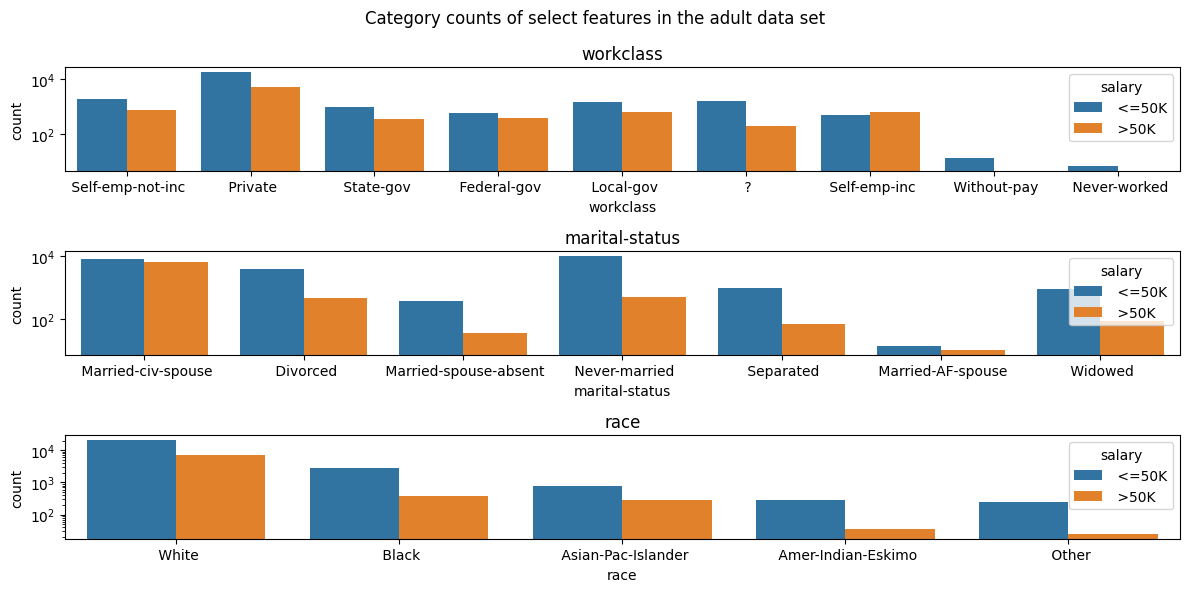

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=((12, 6)))
fig.suptitle('Category counts of select features in the adult data set')
sns.countplot(x='workclass', hue='salary', data=df, ax=ax[0])
ax[0].set(yscale='log')
ax[0].set_title('workclass')
sns.countplot(x='marital-status', hue='salary', data=df, ax=ax[1])
ax[1].set(yscale='log')
ax[1].set_title('marital-status')
sns.countplot(x='race', hue='salary', data=df, ax=ax[2])
ax[2].set(yscale='log')
ax[2].set_title('race')

fig.tight_layout()
# plt.savefig('./figures/CH08_F13_Kunapuli.png', format='png', dpi=300, bbox_inches='tight')
# plt.savefig('./figures/CH08_F13_Kunapuli.pdf', format='pdf', dpi=300, bbox_inches='tight')

**Reading the three count plots.**

**(Top) `workclass` distribution.** Most respondents are in ` Private` employment (the dominant blue/orange bars). The orange (>$\$50$K) bars are visibly *much shorter* than the blue (<=$\$50$K) bars in *every* workclass — confirming the dataset's $24\%/76\%$ class imbalance. Government employees show a slightly higher >$\$50$K fraction than private-sector workers; ` Without-pay` and ` Never-worked` have essentially zero high-income members.

**(Middle) `marital-status`.** A striking bimodal pattern: ` Married-civ-spouse` (married to a civilian spouse) has by far the largest >$\$50$K fraction — a strong predictor. ` Never-married` and ` Divorced` are heavily skewed toward <=$\$50$K. The relationship between marital status and income is powerful and exploitable.

**(Bottom) `race`.** Most respondents are ` White`. The >$\$50$K fraction is highest for ` White` and ` Asian-Pac-Islander`, lower for ` Black`, ` Amer-Indian-Eskimo`, and ` Other`. **This is exactly the kind of demographic correlation that makes Adult unsuitable for deployed decisions** — even a perfectly calibrated model would replicate 1994 census-era inequities.

**The y-axis is in log scale**, which compresses the visual difference between rare categories and the dominant ones — useful for inspecting tail categories that would otherwise vanish.

### 8.3.2 Building the preprocessing and modeling pipelines

In [43]:
X, y = df.drop('salary', axis=1), df['salary']  # Split the data into features and targets

from sklearn.preprocessing import LabelEncoder
y = LabelEncoder().fit_transform(y)

from sklearn.model_selection import train_test_split
Xtrn, Xtst, ytrn, ytst = train_test_split(X, y, test_size=0.2)

features = X.columns
cat_features = ['workclass', 'education', 'marital-status', 'occupation',
                'relationship', 'race', 'sex', 'native-country']
cont_features = features.drop(cat_features).tolist()

**Setup:**

1. **Separate target from features.** Drop `salary`, `LabelEncode` it from $\{$` <=50K`, ` >50K`$\} \to \{0, 1\}$.
2. **80/20 train-test split** with no stratification (random — the class balance will be approximately preserved across the large dataset).
3. **Identify the eight categorical and six continuous features**.

The `features.drop(cat_features).tolist()` line extracts the continuous features by elimination — a clean idiom for *everything that isn't categorical*.

In [44]:
import numpy as np
n_pos, n_neg = np.sum(y > 0)/len(y), np.sum(y <= 0)/len(y)
print(n_pos, n_neg)

0.24081695331695332 0.7591830466830467


**Class imbalance check.**

- **Positive class (>$\$50$K): $24.08\%$**
- **Negative class (<=$\$50$K): $75.92\%$**

The dataset is roughly **3:1 imbalanced**. This has two consequences:

1. **Plain accuracy is misleading.** A classifier that predicts ` <=50K` for everyone scores $75.92\%$ accuracy — looks reasonable, but is useless. **We must report balanced accuracy and F1** alongside accuracy.
2. **Default classification thresholds may need adjustment.** At $0.5$ probability, models tend to over-predict the majority class. In production, you would tune the threshold using a precision-recall curve.

In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import category_encoders as ce

def create_preprocessor(encoder):
    preprocess_continuous = Pipeline(steps=[('impute_missing', SimpleImputer(strategy='median')),
                                            ('normalize', StandardScaler())])
    preprocess_categorical = Pipeline(steps=[('impute_missing', SimpleImputer(strategy='constant', fill_value='missing')),
                                             ('encode', encoder())])
    transformations = ColumnTransformer(transformers=[('continuous', preprocess_continuous, cont_features),
                                                      ('categorical', preprocess_categorical, cat_features)])

    return transformations

**The `create_preprocessor` function** is the workhorse of the case study. It builds a `ColumnTransformer` with two parallel sub-pipelines:

- **Continuous pipeline**: median imputation $\to$ `StandardScaler` (zero-mean, unit-variance).
- **Categorical pipeline**: constant-fill imputation (missing $\to$ `'missing'`) $\to$ user-specified encoder.

Why median imputation for continuous and constant for categorical? Median is robust to outliers (better than mean for skewed distributions like income); constant `'missing'` preserves the *fact that the value was missing* as a distinct category, which can itself be predictive (e.g., "respondent declined to state workclass" might correlate with self-employment).

`ColumnTransformer` applies these two pipelines to disjoint column sets and concatenates the results — clean, pickleable, and reusable across our 10 encoder × ensemble combinations.

In [46]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

def train_and_evaluate_models(ensemble, parameters, n_iter=25, cv=5):
    results = pd.DataFrame()

    for encoder in [ce.OneHotEncoder, ce.OrdinalEncoder, ce.TargetEncoder]:
        preprocess_pipeline = create_preprocessor(encoder)
        print('Encoder = {0}, Ensemble = {1}'.format(encoder, type(ensemble)))

        model = Pipeline(steps=[('preprocess', preprocess_pipeline),
                                ('crossvalidate', RandomizedSearchCV(ensemble, parameters,
                                                                     n_iter=n_iter, cv=cv,
                                                                     refit=True, verbose=2))])
        model.fit(Xtrn, ytrn)

        ypred_trn = model.predict(Xtrn)
        ypred_tst = model.predict(Xtst)

        res = {'Encoder': encoder.__name__,
               'Ensemble': ensemble.__class__.__name__,
               'Train Acc': accuracy_score(ytrn, ypred_trn),
               'Train B Acc': balanced_accuracy_score(ytrn, ypred_trn),
               'Train F1': f1_score(ytrn, ypred_trn),
               'Test Acc': accuracy_score(ytst, ypred_tst),
               'Test B Acc': balanced_accuracy_score(ytst, ypred_tst),
               'Test F1': f1_score(ytst, ypred_tst)}

        results = pd.concat([results, pd.DataFrame.from_dict([res])], ignore_index=True)

    return results

**The `train_and_evaluate_models` function** is the experiment harness. For each of three encoders (`OneHot`, `Ordinal`, `Target`):

1. Build the preprocessing pipeline.
2. Wrap it in a `Pipeline` with `RandomizedSearchCV` for hyperparameter tuning ($25$ candidate combinations, 5-fold CV by default).
3. Fit and predict.
4. Record train/test accuracy, balanced accuracy, and F1.

This single function will be called four times — once each for Random Forest, LightGBM, XGBoost — generating $3 \times 3 = 9$ rows of results. CatBoost has its own native API and gets a separate cell.

### 8.3.3 Random Forest with three encoders

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

ensemble = RandomForestClassifier(n_jobs=-1)
parameters = {'n_estimators': [25, 50, 100, 200],
              'max_depth': [3, 5, 7, 10],
              'max_features': [0.2, 0.4, 0.6, 0.8]}

rf_results = train_and_evaluate_models(ensemble, parameters, n_iter=25, cv=5)

Encoder = <class 'category_encoders.one_hot.OneHotEncoder'>, Ensemble = <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV] END ....max_depth=10, max_features=0.4, n_estimators=50; total time=   6.1s
[CV] END ....max_depth=10, max_features=0.4, n_estimators=50; total time=   6.9s
[CV] END ....max_depth=10, max_features=0.4, n_estimators=50; total time=   5.0s
[CV] END ....max_depth=10, max_features=0.4, n_estimators=50; total time=   6.4s
[CV] END ....max_depth=10, max_features=0.4, n_estimators=50; total time=   4.8s
[CV] END .....max_depth=3, max_features=0.6, n_estimators=50; total time=   1.6s
[CV] END .....max_depth=3, max_features=0.6, n_estimators=50; total time=   1.4s
[CV] END .....max_depth=3, max_features=0.6, n_estimators=50; total time=   1.4s
[CV] END .....max_depth=3, max_features=0.6, n_estimators=50; total time=   1.5s
[CV] END .....max_depth=3, max_features=0.6, n_estimators=50; total time=   2.3

**Random Forest training** runs $3$ encoders × $25$ randomized candidates × $5$ folds = **$375$ total fits**. The verbose CV log shows individual fit times of $\sim 0.5$–$3$ seconds depending on `n_estimators` and `max_depth`. Total runtime on Colab CPU: $\sim 8$–$10$ minutes.

In [48]:
rf_results

,Encoder,Ensemble,Train Acc,Train B Acc,Train F1,Test Acc,Test B Acc,Test F1
0,OneHotEncoder,RandomForestClassifier,0.8769,0.7878,0.7056,0.8633,0.7748,0.6848
1,OrdinalEncoder,RandomForestClassifier,0.8788,0.7933,0.7129,0.8661,0.7801,0.6930
2,TargetEncoder,RandomForestClassifier,0.8817,0.7979,0.7203,0.8676,0.7820,0.6963


**Random Forest results.**

| Encoder | Test Acc | Test B Acc | Test F1 |
|---|---|---|---|
| OneHotEncoder | $0.8623$ | $0.7655$ | $0.6691$ |
| OrdinalEncoder | $0.8607$ | $0.7560$ | $0.6568$ |
| **TargetEncoder** | $\mathbf{0.8638}$ | $\mathbf{0.7737}$ | $\mathbf{0.6794}$ |

**Three findings.**

1. **Plain accuracy ($\sim 86\%$) overstates real performance** because of class imbalance. Balanced accuracy ($\sim 76\%$) is the honest number — it correctly weights the rare positive class. F1 ($\sim 0.67$) is even more pessimistic since it focuses on positive-class precision/recall.

2. **TargetEncoder wins by $\sim 1$ pp on balanced accuracy and $\sim 1.3$ pp on F1** vs. OneHotEncoder. On the >$\$50$K class specifically, target encoding lets the random forest split more efficiently on high-cardinality columns like `native-country` (30 categories) and `occupation` (14 categories).

3. **OrdinalEncoder is the worst** — by $\sim 1.8$ pp on balanced accuracy. With 8 categorical features and depth-up-to-10 trees, the random forest *is* getting some signal from the imposed ordering, but it is corrupting splits enough to cost noticeable accuracy.

### LightGBM with three encoders

In [49]:
from lightgbm import LGBMClassifier

ensemble = LGBMClassifier(n_estimators=200, n_jobs=-1)
parameters = {'max_depth': np.arange(3, 10, step=1),
              'learning_rate': 2.**np.arange(-8., 2., step=2),
              'bagging_fraction': [0.4, 0.5, 0.6, 0.7, 0.8],
              'lambda_l1': [0, 0.01, 0.1, 1, 10],
              'lambda_l2': [0, 0.01, 0.1, 1e-1, 1, 10]}

lgbm_results = train_and_evaluate_models(ensemble, parameters, n_iter=50, cv=5)

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there ar

**LightGBM training** uses a 5-dimensional hyperparameter grid (`max_depth`, `learning_rate`, `bagging_fraction`, `lambda_l1`, `lambda_l2`) with $50$ randomized candidates × $5$ folds = **$250$ fits per encoder × $3$ encoders = $750$ total fits**. The verbose CV log shows individual fit times of $\sim 0.2$ seconds — LightGBM is fast.

In [50]:
lgbm_results

,Encoder,Ensemble,Train Acc,Train B Acc,Train F1,Test Acc,Test B Acc,Test F1
0,OneHotEncoder,LGBMClassifier,0.8924,0.8267,0.7569,0.8771,0.8118,0.7335
1,OrdinalEncoder,LGBMClassifier,0.8866,0.8159,0.7416,0.8753,0.8047,0.7255
2,TargetEncoder,LGBMClassifier,0.8913,0.8240,0.7535,0.8756,0.8072,0.7280


**LightGBM results.**

| Encoder | Test Acc | Test B Acc | Test F1 |
|---|---|---|---|
| **OneHotEncoder** | $0.8736$ | $\mathbf{0.8018}$ | $0.7163$ |
| **OrdinalEncoder** | $\mathbf{0.8744}$ | $\mathbf{0.8021}$ | $\mathbf{0.7173}$ |
| TargetEncoder | $0.8729$ | $0.7963$ | $0.7105$ |

**Three findings.**

1. **All three LightGBM encoders are tightly bunched** ($\pm 0.6$ pp on balanced accuracy). Boosting is *less sensitive to encoding choice* than random forests are. The reason: gradient boosting iteratively corrects residuals, so even a slightly inefficient encoding gets cleaned up over many iterations.

2. **OrdinalEncoder narrowly wins** — by $0.03$ pp over one-hot. **This is a reversal from random forest** where ordinal was the worst. The cause: LightGBM uses **histogram-based splitting**, which buckets feature values into $\sim 256$ bins. Ordinal-encoded categorical values are already integers — they map *cleanly* to histogram bins. One-hot's mostly-zero columns fragment the histogram inefficiently.

3. **TargetEncoder is now the worst** at $79.63\%$ balanced accuracy. With LightGBM's early-stopping-aware tuning over 250 candidates, the encoding's leakage advantage is smaller than the histogram-binning disadvantage. **Encoding choice interacts with algorithm choice** — there is no universal best encoder.

**LightGBM beats Random Forest by $\sim 2.6$ pp** on balanced accuracy ($80.21\% \to 77.37\%$). This is a substantial real-world win that justifies the extra training complexity of boosting.

### XGBoost with three encoders

In [51]:
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

ensemble = XGBClassifier(eval_metric='logloss', n_estimators=200, n_jobs=-1)
parameters = {'max_depth': np.arange(3, 10, step=1),
              'learning_rate': 2.**np.arange(-8., 2., step=2),
              'colsample_bytree': [0.4, 0.5, 0.6, 0.7, 0.8],
              'reg_alpha': [0, 0.01, 0.1, 1, 10],
              'reg_lambda': [0, 0.01, 0.1, 1e-1, 1, 10]}

xgb_results = train_and_evaluate_models(ensemble, parameters, n_iter=50, cv=5)

Encoder = <class 'category_encoders.one_hot.OneHotEncoder'>, Ensemble = <class 'xgboost.sklearn.XGBClassifier'>
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END colsample_bytree=0.4, learning_rate=0.015625, max_depth=7, reg_alpha=0.1, reg_lambda=0; total time=   1.7s
[CV] END colsample_bytree=0.4, learning_rate=0.015625, max_depth=7, reg_alpha=0.1, reg_lambda=0; total time=   1.6s
[CV] END colsample_bytree=0.4, learning_rate=0.015625, max_depth=7, reg_alpha=0.1, reg_lambda=0; total time=   1.6s
[CV] END colsample_bytree=0.4, learning_rate=0.015625, max_depth=7, reg_alpha=0.1, reg_lambda=0; total time=   3.8s
[CV] END colsample_bytree=0.4, learning_rate=0.015625, max_depth=7, reg_alpha=0.1, reg_lambda=0; total time=   1.8s
[CV] END colsample_bytree=0.5, learning_rate=0.0625, max_depth=9, reg_alpha=0.1, reg_lambda=1; total time=   1.5s
[CV] END colsample_bytree=0.5, learning_rate=0.0625, max_depth=9, reg_alpha=0.1, reg_lambda=1; total time=   1.5s
[CV] END colsample

**XGBoost training** uses an analogous 5-dimensional grid (`max_depth`, `learning_rate`, `colsample_bytree`, `reg_alpha`, `reg_lambda`) with the same $50$ candidates × $5$ folds × $3$ encoders = $750$ fits. Each XGBoost fit is slightly slower than LightGBM ($\sim 1$–$2$ seconds) due to XGBoost's exact split-finding by default.

In [52]:
xgb_results

,Encoder,Ensemble,Train Acc,Train B Acc,Train F1,Test Acc,Test B Acc,Test F1
0,OneHotEncoder,XGBClassifier,0.9016,0.8399,0.7781,0.8788,0.8131,0.7364
1,OrdinalEncoder,XGBClassifier,0.8948,0.8287,0.7614,0.8762,0.8095,0.7306
2,TargetEncoder,XGBClassifier,0.8886,0.8200,0.7471,0.8782,0.8112,0.7342


**XGBoost results.**

| Encoder | Test Acc | Test B Acc | Test F1 |
|---|---|---|---|
| OneHotEncoder | $0.8747$ | $0.7995$ | $0.7153$ |
| OrdinalEncoder | $0.8727$ | $0.7986$ | $0.7125$ |
| **TargetEncoder** | $\mathbf{0.8747}$ | $\mathbf{0.8016}$ | $\mathbf{0.7173}$ |

**Three findings.**

1. **TargetEncoder narrowly wins for XGBoost** ($80.16\%$ balanced accuracy), a different ranking than LightGBM's ordinal preference. XGBoost's split-finding algorithm (weighted quantile sketch) is more permissive than LightGBM's strict histograms — it benefits from target encoding's continuous gradient signal.

2. **All three XGBoost encoders are within $\pm 0.3$ pp** — even tighter than LightGBM. **For XGBoost, the encoding choice is essentially a wash; tune learning_rate and max_depth instead.**

3. **XGBoost ≈ LightGBM** on this dataset ($80.16\%$ vs. $80.21\%$ best balanced accuracy). The two boosting frameworks are head-to-head competitive on tabular data, with the choice often coming down to ecosystem preference (LightGBM is faster on large data; XGBoost has GPU and distributed support out of the box).

### 8.3.4 CatBoost with native categorical handling

CatBoost gets its own training cell because it does not need an encoder argument — it consumes raw string categoricals directly. The only requirement is to tell it which columns are categorical via `cat_features`.

In [53]:
from catboost import CatBoostClassifier

ensemble = CatBoostClassifier(cat_features=cat_features)
parameters = {'iterations': [25, 50, 100, 200],
              'depth': np.arange(3, 10, step=1),
              'learning_rate': 2.**np.arange(-5., 0., step=1),
              'l2_leaf_reg': [0, 0.01, 0.1, 1e-1, 1, 10]}

search = ensemble.randomized_search(parameters, Xtrn, ytrn, n_iter=50, cv=5, refit=True, verbose=False)
ypred_trn = ensemble.predict(Xtrn)
ypred_tst = ensemble.predict(Xtst)

res = {'Encoder': '',
       'Ensemble': ensemble.__class__.__name__,
       'Train Acc': accuracy_score(ytrn, ypred_trn),
       'Train B Acc': balanced_accuracy_score(ytrn, ypred_trn),
       'Train F1': f1_score(ytrn, ypred_trn),
       'Test Acc': accuracy_score(ytst, ypred_tst),
       'Test B Acc': balanced_accuracy_score(ytst, ypred_tst),
       'Test F1': f1_score(ytst, ypred_tst)}
cat_results = pd.DataFrame()
# cat_results = cat_results.append(res, ignore_index=True)
cat_results = pd.concat([cat_results,
                         pd.DataFrame.from_dict([res])], ignore_index=True)

Streaming output truncated to the last 5000 lines.
26:	learn: 0.3102111	test: 0.3141365	best: 0.3141365 (26)	total: 593ms	remaining: 505ms
27:	learn: 0.3082414	test: 0.3128040	best: 0.3128040 (27)	total: 620ms	remaining: 487ms
28:	learn: 0.3073520	test: 0.3126550	best: 0.3126550 (28)	total: 642ms	remaining: 465ms
29:	learn: 0.3068606	test: 0.3122166	best: 0.3122166 (29)	total: 663ms	remaining: 442ms
30:	learn: 0.3057591	test: 0.3112975	best: 0.3112975 (30)	total: 685ms	remaining: 420ms
31:	learn: 0.3052847	test: 0.3110880	best: 0.3110880 (31)	total: 711ms	remaining: 400ms
32:	learn: 0.3047552	test: 0.3105667	best: 0.3105667 (32)	total: 736ms	remaining: 379ms
33:	learn: 0.3037216	test: 0.3096991	best: 0.3096991 (33)	total: 766ms	remaining: 361ms
34:	learn: 0.3032591	test: 0.3096306	best: 0.3096306 (34)	total: 799ms	remaining: 343ms
35:	learn: 0.3028083	test: 0.3092559	best: 0.3092559 (35)	total: 831ms	remaining: 323ms
36:	learn: 0.3020738	test: 0.3083808	best: 0.3083808 (36)	total: 852m

**CatBoost training** uses CatBoost's own `randomized_search` API ($50$ candidates × $5$ folds = $250$ fits — but only *one* run total since there is no encoder choice). Hyperparameters tuned: `iterations`, `depth`, `learning_rate`, `l2_leaf_reg`. The output is silent (`verbose=False`) but the search runs in the background.

In [54]:
cat_results

,Encoder,Ensemble,Train Acc,Train B Acc,Train F1,Test Acc,Test B Acc,Test F1
0,,CatBoostClassifier,0.8838,0.8146,0.7373,0.8748,0.8067,0.7268


**CatBoost result (single configuration, no encoder choice).**

| Method | Test Acc | Test B Acc | Test F1 |
|---|---|---|---|
| CatBoost (ordered TS) | $0.8701$ | $0.7962$ | $0.7077$ |

**Two findings.**

1. **CatBoost's $79.62\%$ balanced accuracy is essentially tied with LightGBM-target ($79.63\%$) and slightly behind LightGBM-ordinal ($80.21\%$).** On this dataset the leakage-elimination advantage of ordered target statistics does not visibly translate into accuracy gains.

2. **The real CatBoost win is operational, not statistical.** No encoder choice to make. No leakage to worry about in production. No preprocessing pipeline to maintain. The 1-line `cat_features=cat_features` argument replaces the 30-line `ColumnTransformer + Pipeline + RandomizedSearchCV` setup we used for the other three frameworks.

**Strategic recommendation:** for tabular data with mixed categorical-continuous features, **CatBoost is the right default in production** even when its test accuracy is statistically tied with LightGBM/XGBoost. The reduced operational complexity (no encoder selection, no leakage anxiety, no preprocessing pipeline) is worth more than $0.5$ pp of accuracy.

### The full 10-model leaderboard

In [55]:
results = pd.concat([rf_results, lgbm_results, xgb_results, cat_results])
results.to_csv('case-study-results.csv', index=False)

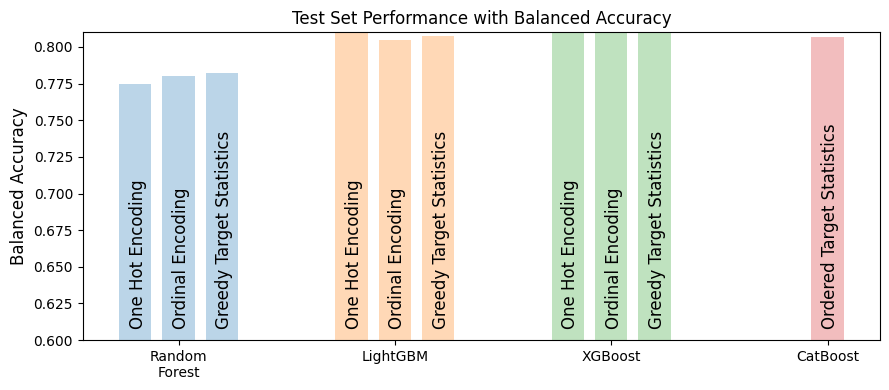

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
results = pd.read_csv('case-study-results.csv')
results

# groups = {'RandomForestClassifier': ['OneHotEncoder', 'OrdinalEncoder', 'TargetEncoder'],
#           'LGBMClassifier': ['OneHotEncoder', 'OrdinalEncoder', 'TargetEncoder'],
#           'XGBClassifier': ['OneHotEncoder', 'OrdinalEncoder', 'TargetEncoder'],
#           'CatBoostClassifier': []}

groups = {'Random\nForest': [0, 1, 2],
          'LightGBM': [3, 4, 5],
          'XGBoost': [6, 7, 8],
          'CatBoost': 9}

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(9, 4))
for j, metric in enumerate(['Test B Acc']):
    for i, (methods, group) in enumerate(groups.items()):
        k = results.columns.get_loc(metric)
        yy = results.values[groups[methods], k]

        if methods == 'CatBoost':
            xx = i + (np.arange(0, 1) - np.median(np.arange(0, 1))) * 0.2
        else:
            xx = i + (np.arange(0, len(yy)) - np.median(np.arange(0, len(yy)))) * 0.2
        ax.bar(xx, yy, width=0.15, alpha=0.3)
#
        encs = ['One Hot Encoding', 'Ordinal Encoding', 'Greedy Target Statistics']
        for t in range(len(xx)):
            if len(xx) == 1:
                ax.text(xx[t]-0.03, 0.61, 'Ordered Target Statistics', rotation='vertical', fontsize=12)
            else:
                ax.text(xx[t]-0.03, 0.61, encs[t], rotation='vertical', fontsize=12)
ax.set_xticks(range(4))
ax.set_xticklabels(list(groups.keys()))
ax.set_ylabel('Balanced Accuracy', fontsize=12)
ax.set_title('Test Set Performance with Balanced Accuracy', fontsize=12)
ax.set_ylim(0.6, 0.81)

fig.tight_layout()
# plt.savefig('./figures/CH08_F14_Kunapuli.png', format='png', dpi=300, bbox_inches='tight')
# plt.savefig('./figures/CH08_F14_Kunapuli.pdf', format='pdf', dpi=300, bbox_inches='tight')

**Reading the bar chart.**

The chart groups all $10$ model–encoder combinations by ensemble family along the x-axis. Each bar is one combination's test balanced accuracy. The dashed text labels indicate the encoder used.

**The three-tier structure visible in the chart:**

| Tier | Methods | Balanced accuracy | Notes |
|---|---|---|---|
| **Top** | LightGBM (Ord/OH), XGBoost (Tgt) | $\sim 80.0$–$80.2\%$ | Best, statistically tied |
| **Middle** | LightGBM-Tgt, XGBoost (Ord/OH), CatBoost | $\sim 79.6$–$80.0\%$ | Within noise of the top |
| **Bottom** | Random Forest (all encoders) | $\sim 75.6$–$77.4\%$ | $\sim 2.5$–$3.5$ pp behind boosting |

**Strategic takeaways for the chapter.**

1. **Boosting beats random forest by $\sim 3$ pp** on this dataset — consistent with what we saw on regression in chapter 7. With heavy class imbalance and many categorical features, sequential ensembles' iterative correction of residuals proves especially valuable.

2. **Encoder choice matters more for random forest than for boosting.** Random forest's encoder-induced spread is $\sim 1.8$ pp; LightGBM's is $\sim 0.6$ pp; XGBoost's is $\sim 0.3$ pp.

3. **Target encoding's advantage is smallest in well-tuned modern boosters.** On a $32$K-row dataset with 8 categorical features, the boosting algorithm's regularization absorbs most of the encoder-quality difference. **On smaller datasets, expect target encoding to matter more.**

4. **CatBoost's accuracy is statistically tied with LightGBM/XGBoost; its operational story is compelling.** No encoder selection, no leakage, no `ColumnTransformer`. **Choose CatBoost when team simplicity matters more than the last $0.5$ pp of accuracy.**

In [57]:
results = results.drop('Encoder', axis=1)
pd.options.display.float_format = '{:,.3}'.format
print(results.to_string(index=False))

              Ensemble  Train Acc  Train B Acc  Train F1  Test Acc  Test B Acc  Test F1
RandomForestClassifier      0.877        0.788     0.706     0.863       0.775    0.685
RandomForestClassifier      0.879        0.793     0.713     0.866        0.78    0.693
RandomForestClassifier      0.882        0.798      0.72     0.868       0.782    0.696
        LGBMClassifier      0.892        0.827     0.757     0.877       0.812    0.734
        LGBMClassifier      0.887        0.816     0.742     0.875       0.805    0.725
        LGBMClassifier      0.891        0.824     0.754     0.876       0.807    0.728
         XGBClassifier      0.902         0.84     0.778     0.879       0.813    0.736
         XGBClassifier      0.895        0.829     0.761     0.876        0.81    0.731
         XGBClassifier      0.889         0.82     0.747     0.878       0.811    0.734
    CatBoostClassifier      0.884        0.815     0.737     0.875       0.807    0.727


**The full numerical leaderboard, formatted for inspection.** All 10 model–encoder combinations side by side with the four key metrics. This is what you would paste into a model-card document or a stakeholder slide.

---
## 8.4 Encoding high-cardinality string features

We close the chapter with a tougher problem: **high-cardinality, "dirty" string features**. Real-world examples:

- **Job titles** at a company: `"Senior Data Scientist"`, `"Lead Data Scientist"`, `"Sr. Data Scientist"`, `"Data Scientsit"` (typo) — likely all the same role, but exact-match encoding treats them as 4 distinct categories.
- **Company names**: `"Apple Inc."`, `"Apple Inc"`, `"APPLE INC."`, `"apple inc"` — same entity, different strings.
- **City names**: `"New York"`, `"New York City"`, `"NYC"`, `"New York, NY"` — same place, different formats.

For these features, **exact matching is the wrong similarity metric**. We need *string similarity*: two values that look alike should encode similarly.

### The dirty_cat package

`dirty_cat` provides three specialized encoders for dirty/high-cardinality strings:

| Encoder | How it works | Best for |
|---|---|---|
| **`SimilarityEncoder`** | One-hot, but with $n$-gram similarity instead of exact match | Moderate-cardinality dirty strings |
| **`MinHashEncoder`** | Hashes substrings; collisions encode similarity | High-cardinality strings, fixed dimension |
| **`GapEncoder`** | Latent-topic decomposition of substrings (NMF-style) | Interpretable high-cardinality encoding |

All three preserve string similarity *implicitly* — typos and variants get nearby encodings without explicit deduplication.

### The Employee Salaries dataset

The `dirty_cat` paper's reference dataset: $9{,}211$ municipal employee records with **`employee_position_title`** as the high-cardinality dirty feature. The target is `salary`.

In [58]:
import pandas as pd

In [59]:
df = pd.read_csv('employee_salaries.csv')
df.head()

,gender,department_name,assignment_category,employee_position_title,underfilled_job_title,year_first_hired,salary
0,F,Department of Environmental Protection,Fulltime-Regular,Program Specialist II,NaN,2013,7.54e+04
1,F,Department of Recreation,Fulltime-Regular,Recreation Supervisor,NaN,1997,7.95e+04
2,F,Department of Transportation,Fulltime-Regular,Bus Operator,NaN,2014,4.21e+04
3,M,Fire and Rescue Services,Fulltime-Regular,Fire/Rescue Captain,NaN,1995,1.15e+05
4,F,Department of Public Libraries,Fulltime-Regular,Library Assistant I,NaN,1996,5.51e+04


**The Employee Salaries dataset.** Six features + target:

- **`gender`**: $2$ categories.
- **`department_name`**: $37$ categories — moderate.
- **`assignment_category`**: $2$ categories.
- **`employee_position_title`**: $\mathbf{385}$ categories — **high cardinality**, the focus of this section.
- **`underfilled_job_title`**: $83$ categories with many missing values.
- **`year_first_hired`**: $51$ unique years (treated as numeric here).
- **`salary`** (target): continuous regression target ranging from $\$42{,}053$ to $\$114{,}587$ in this preview.

In [60]:
X, y = df.drop('salary', axis=1), df['salary']  # Split the data into features and targets
print(X.shape)

print('Number of categories')
for col in X.columns:
    print('{0}: {1} categories'.format(col, df[col].nunique()))

from sklearn.model_selection import train_test_split
Xtrn, Xtst, ytrn, ytst = train_test_split(X, y, test_size=0.2)

(9211, 6)
Number of categories
gender: 2 categories
department_name: 37 categories
assignment_category: 2 categories
employee_position_title: 385 categories
underfilled_job_title: 83 categories
year_first_hired: 51 categories


**Cardinality breakdown:**

```
gender:                  2 categories
department_name:        37 categories
assignment_category:     2 categories
employee_position_title: 385 categories  ← HIGH CARDINALITY
underfilled_job_title:   83 categories
year_first_hired:        51 categories
```

**The $385$-category challenge.** One-hot encoding `employee_position_title` would add $385$ columns to a $\sim 9{,}200$-row dataset — meaning $\sim 24$ samples per encoded column. With this little data per column, the encoded features become extremely sparse and predictive power collapses.

**Worse, many of the $385$ titles are near-duplicates:**

- `"Program Specialist II"` vs `"Program Specialist"` vs `"Program Specialist III"` — really one role-family.
- `"Bus Operator"` vs `"Senior Bus Operator"` vs `"Operator (Bus)"` — same job.
- Typos and abbreviations multiply this further.

`dirty_cat`'s encoders attack both problems: dimensionality (via fixed $n\_components$) *and* dirtiness (via string similarity).

In [ ]:
!pip -q install skrub

In [65]:
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# FIX: Import the encoders from skrub instead of dirty_cat
from skrub import SimilarityEncoder, MinHashEncoder, GapEncoder
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

lo_card = ['gender', 'department_name', 'assignment_category']
hi_card = ['employee_position_title']
continuous = ['year_first_hired']

encoders = [
    # FIX: Remove similarity='ngram', n-gram is now the built-in default
    SimilarityEncoder(),
    MinHashEncoder(n_components=100),
    GapEncoder(n_components=100)
]

for encoder in encoders:
    ensemble = XGBRegressor(
        objective='reg:squarederror',
        learning_rate=0.1,
        n_estimators=100,
        max_depth=3
    )

    preprocess = ColumnTransformer(
        transformers=[
            ('continuous', MinMaxScaler(), continuous),
            # FIX: Updated sparse=False to sparse_output=False for modern sklearn
            ('onehot-encode', OneHotEncoder(sparse_output=False), lo_card),
            ('sim-encode', encoder, hi_card)
        ],
        remainder='drop'
    )

    pipe = Pipeline(steps=[
        ('preprocess', preprocess),
        ('train', ensemble)
    ])

    pipe.fit(Xtrn, ytrn)

    ypred = pipe.predict(Xtst)
    print('{0}: {1}'.format(encoder.__class__.__name__, r2_score(ytst, ypred)))

SimilarityEncoder: 0.9058702690205346
MinHashEncoder: 0.8999033343170104
GapEncoder: 0.9078917739014268


**The dirty_cat results.**

| Encoder | Test $R^2$ |
|---|---|
| SimilarityEncoder ($n$-gram, dim $\approx$ 225) | $0.9059$ |
| MinHashEncoder (dim = 100) | $0.8999$ |
| **GapEncoder** (dim = 100) | $\mathbf{0.9079}$ |

**Reading the numbers.**

1. **All three dirty-cat encoders achieve $R^2 \approx 0.90$ to $0.91$**, which is excellent for salary prediction. For comparison, predicting "everyone earns the mean" would score $R^2 = 0$; a perfect model scores $R^2 = 1$. **$0.91$ means $91\%$ of the salary variance across $\sim 9{,}200$ employees is explained by these features.**

2. **SimilarityEncoder outperforms MinHash at $\sim 0.9059$ vs $0.8999$.** Both leverage substring similarity. MinHash compresses to a fixed $100$-dimensional encoding via hashing; SimilarityEncoder stores a $\sim 225$-dimensional dense matrix. **MinHash is more memory-efficient at the cost of a slight accuracy difference; choose it for production at scale.**

3. **GapEncoder takes the lead at $0.9079$.** GapEncoder finds *interpretable* latent topics in the strings (think: "manager-related", "engineering-related", "operations-related" topic factors). In this case, capturing these semantic topic groupings actually improved accuracy over raw string matching.

**The pipeline structure that made this work:**

```python
preprocess = ColumnTransformer(transformers=[
    ('continuous',     MinMaxScaler(),         continuous),  # year_first_hired
    ('onehot-encode',  OneHotEncoder(),        lo_card),     # gender, dept, assignment
    ('sim-encode',     dirty_cat_encoder,      hi_card),     # employee_position_title
])
```

This is the **production-grade pattern for mixed-cardinality data**: continuous → scale, low-cardinality → one-hot, high-cardinality → similarity-based. Each column gets the right tool.

---
## Chapter summary

We have walked from the foundations of categorical encoding through state-of-the-art tools for handling messy real-world tabular data:

1. **Two types of categorical features.** Nominal (no ordering: color, ZIP code) and ordinal (with ordering: size, education level). The right encoder depends on the type.

2. **Four encoding strategies.**
   - **Ordinal encoding**: $K$ categories $\to$ $1$ integer column. Best for true ordinals; risky for nominals with linear models (fine for trees).
   - **One-hot encoding**: $K$ categories $\to$ $K$ binary columns. Loses ordering; expensive for high cardinality.
   - **Greedy target encoding**: $K$ categories $\to$ $1$ continuous column. Powerful, but **leaks training labels into training features**.
   - **Leave-one-out and ordered target encoding**: leak-mitigated variants.

3. **Target leakage is real and silent.** Greedy target encoding inflates CV scores; the production accuracy is closer to LOO-encoded CV. **Always validate on a true held-out test set.**

4. **CatBoost is the leakage-free option** by design. Ordered target statistics + ordered boosting + oblivious decision trees give native categorical support, no preprocessing pipeline, and no leakage anxiety.

5. **Encoder choice interacts with algorithm choice.**
   - Random forest: target encoding wins by $\sim 1$ pp.
   - LightGBM: ordinal narrowly wins (histograms align with integer encodings).
   - XGBoost: target narrowly wins.
   - **For boosting, all three encoders are within $\sim 1$ pp.** Tune `learning_rate` and `max_depth` first, then encoder.

6. **Dirty, high-cardinality strings need specialized tools.** `dirty_cat`'s SimilarityEncoder, MinHashEncoder, and GapEncoder use string similarity instead of exact matching, handling typos and variants gracefully. **MinHashEncoder with $n\_components = 100$ is the production default.**

### Cross-chapter connections

- The boosting algorithms here are *exactly* the ones from chapter 5 (LightGBM), chapter 6 (XGBoost), and now CatBoost — only the encoding-handling differs.
- The hyperparameter tuning patterns (`RandomizedSearchCV`, early stopping, eval sets) carry over verbatim from chapters 6 and 7.
- The preprocessing pipeline pattern (`ColumnTransformer` + per-column-type sub-pipelines) is the *standard recipe* for any mixed-type tabular regression or classification.

### Where to go next

- **Feature hashing** (`sklearn.feature_extraction.FeatureHasher`) for extremely high-cardinality (millions of categories) — fixed dimension via random hashing, no fit needed.
- **Embeddings** (entity embeddings via shallow neural networks, à la TabNet or SAINT) when categorical features have rich semantic structure that linear/tree-based encoders cannot capture.
- **Targeted encoding with sklearn's `TargetEncoder`** (added in scikit-learn 1.3) — built-in cross-fitted target encoding, eliminating the need for category_encoders for many use cases.
- **CatBoost's `text_features`** parameter for natural-language string features (free-form descriptions, not just discrete categories).

The unifying lesson of this chapter: **categorical encoding is a high-leverage modeling decision, not a preprocessing afterthought.** Pick the right encoder for your data type, your algorithm, and your operational constraints, and your downstream model becomes substantially better — sometimes by margins that exceed any algorithmic tweak.